# EDA Parlamentarios

In [1]:
import sys
!{sys.executable} -m pip install Unidecode
!{sys.executable} -m pip install plotly

In [2]:
#Importación de librerías 
import plotly.express as px
import pandas as pd
import unidecode
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import plotly.express as px
#import seaborn as sns
import re

In [57]:
# Leer CSV de parlamentarios
df = pd.read_csv("../data/raw/parlamentarios/ag_actuantes_legislaturas.csv")

# Leer CSV de actuantes
df_actuantes = pd.read_csv("../data/raw/parlamentarios/ag_actuantes_2010_hoy.csv")

# Leer CSV de nacimientos
df_nombres = pd.read_csv("../data/raw/parlamentarios/nombres_personas.csv")
df_nombres.columns = df_nombres.columns.str.lower()


In [58]:
df_actuantes['nombre'].value_counts()

nombre
Ver Titular                         10795
Carballo Da Costa, Felipe            5302
Varela Nestier, Carlos               5240
Niffouri, Amín                       5169
Pasquet Iribarne, Ope                5126
                                    ...  
Rodríguez, Delia                        1
Manini Ríos Moreira, Micaela            1
Clavell Clavero, Fernando Damián        1
Mogni Graña, Analhi                     1
Ackermann, Nair                         1
Name: count, Length: 1273, dtype: int64

In [59]:
# Se extrae el primer nombre de cada parlamentario
df_actuantes["primer_nombre"] = df_actuantes["nombre"].str.split(",").str[1].str.strip().str.split().str[0]

In [60]:
def normalizar_nombre(x):
    if pd.isna(x):
        return None
    x = str(x)
    x = x.strip()                 # quita espacios adelante/atrás
    x = unidecode.unidecode(x)    # quita tildes y caracteres raros
    x = x.lower()                 # todo minúsculas
    return x

In [61]:
#se convierte la variable legislatura a tipo entero para que quede igual al df de intervenciones
# Función para convertir números romanos a enteros
def roman_to_int(roman):
    valores = {
        'I': 1, 'V': 5, 'X': 10, 'L': 50,
        'C': 100, 'D': 500, 'M': 1000
    }
    total = 0
    prev = 0
    for ch in reversed(roman):
        v = valores[ch]
        if v < prev:
            total -= v
        else:
            total += v
        prev = v
    return total


In [62]:
# Columnas: ANIO, SEXO, NOMBRE, NACIMIENTOS
df_nombres['nombre_norm'] = df_nombres['nombre'].apply(normalizar_nombre)

In [63]:
def sexo_dominante(grupo_sexo, grupo_nacimientos):
    # sumamos nacimientos por sexo
    suma = (
        pd.DataFrame({"sexo": grupo_sexo, "nacim": grupo_nacimientos})
        .groupby("sexo")["nacim"]
        .sum()
        .sort_values(ascending=False)
    )
    if len(suma) == 1:
        # solo aparece M o solo F
        return suma.index[0]
    else:
        # si el primero tiene claramente más que el segundo, lo tomamos
        if suma.iloc[0] >= 2 * suma.iloc[1]:
            return suma.index[0]
        else:
            return "X"   # ambiguo
            

tabla_nombres = (
    df_nombres
    .groupby("nombre_norm")
    .apply(lambda g: sexo_dominante(g["sexo"], g["nacimientos"]))
    .reset_index(name="sexo_dominante")
)


C:\Users\flala\AppData\Local\Temp\ipykernel_9796\1150163238.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sexo_dominante(g["sexo"], g["nacimientos"]))


In [64]:
df_actuantes["primer_nombre"] = (
    df_actuantes["nombre"]
      .str.split(",").str[1]
      .str.strip()
      .str.split().str[0]
      .str.lower()
)

# normalizar
df_actuantes['nombre_norm'] = df_actuantes  ['primer_nombre'].apply(normalizar_nombre)

In [65]:
df_legis = df_actuantes.merge(
    tabla_nombres,
    on='nombre_norm',
    how='left'
)

# si no matcheó, marcamos como desconocido
df_legis['sexo_asignado'] = df_legis['sexo_dominante'].fillna('X')



In [66]:
df_legis

,fecha,nombre,partido,camara,condicion,sustituye_a,detalles_texto,fuente_url,primer_nombre,nombre_norm,sexo_dominante,sexo_asignado
0,2010-02-15,"Topolansky, Lucía",FRENTE AMPLIO,CSS,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,lucía,lucia,F,F
1,2010-02-15,"Abreu, Sergio",NACIONAL,CSS,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,sergio,sergio,M,M
2,2010-02-15,"Agazzi, Ernesto",FRENTE AMPLIO,CSS,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,ernesto,ernesto,M,M
3,2010-02-15,"Amorín, José",COLORADO,CSS,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,josé,jose,M,M
4,2010-02-15,"Baráibar, Carlos",FRENTE AMPLIO,CSS,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,carlos,carlos,M,M
...,...,...,...,...,...,...,...,...,...,...,...,...
724381,2025-11-22,"Verri, Walter",COLORADO,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,walter,walter,M,M
724382,2025-11-22,"Viera Dutruel, Mauricio Omar",COLORADO,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,mauricio,mauricio,M,M
724383,2025-11-22,"Zavala, Alejandro",FRENTE AMPLIO,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,alejandro,alejandro,M,M
724384,2025-11-22,"de Armas González, María Paula",COLORADO,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,maría,maria,F,F


In [67]:
df_legis['sexo_asignado'].value_counts()

sexo_asignado
M    549044
F    155223
X     20119
Name: count, dtype: int64

In [68]:
df_legis['sexo_dominante'].value_counts()

sexo_dominante
M    549044
F    155223
X      2115
Name: count, dtype: int64

In [69]:
df_sexo_x = df_legis[df_legis['sexo_asignado'] == 'X']

df_sexo_x

,fecha,nombre,partido,camara,condicion,sustituye_a,detalles_texto,fuente_url,primer_nombre,nombre_norm,sexo_dominante,sexo_asignado
76,2010-02-15,Ver Titular,NACIONAL,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,NaN,None,NaN,X
89,2010-02-15,"Osorio, Marne",COLORADO,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,marne,marne,X,X
142,2010-02-16,Ver Titular,FRENTE AMPLIO,CSS,Actuante,"la Senadora Topolansky, Lucía durante el pasaj...",NaN,https://parlamento.gub.uy/sobreelparlamento/in...,NaN,None,NaN,X
219,2010-02-16,"Osorio, Marne",COLORADO,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,marne,marne,X,X
273,2010-02-17,Ver Titular,FRENTE AMPLIO,CSS,Actuante,"la Senadora Topolansky, Lucía durante el pasaj...",NaN,https://parlamento.gub.uy/sobreelparlamento/in...,NaN,None,NaN,X
...,...,...,...,...,...,...,...,...,...,...,...,...
724242,2025-11-21,Sin suplente convocado,COLORADO,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,NaN,None,NaN,X
724262,2025-11-22,Ver Titular,FRENTE AMPLIO,CSS,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,NaN,None,NaN,X
724296,2025-11-22,Ver Titular,NACIONAL,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,NaN,None,NaN,X
724350,2025-11-22,"Osorio, Marne",COLORADO,CRR,Actuante,NaN,NaN,https://parlamento.gub.uy/sobreelparlamento/in...,marne,marne,X,X


In [70]:

df_sexo_x['nombre'].value_counts()

nombre
Ver Titular                     10795
Sin suplente convocado           2700
Osorio, Marne                    2057
Camargo, Nazmi                   1805
Ezquerra Alonso, W. Aparicio     1517
Silva, Rubenson                   754
López, Narcio                     180
Ferrari, Gletel                    99
Sena, Estacio                      74
Fernández, Diver                   58
Martínez, Jodami                   30
Rodríguez, Vilibaldo               26
Leal Alvarez, Auber Agapito        23
Mogni Graña, Analhi                 1
Name: count, dtype: int64

In [71]:
# se imputan a mano los sexos de los  y las parlamentarias con nombre no encontrado
imputaciones = {
    'Osorio, Marne': 'M',
    'López, Narcio': 'M',
    'Camargo, Nazmi': 'F',         
    'Silva, Rubenson': 'M',
    'Martínez, Jodami': 'F',
    'Sena, Estacio': 'M',
    'Fernández, Diver': 'M', 
    'Mogni Graña, Analhi': 'F',
    'Rodríguez, Vilibaldo': 'M',
    'Ferrari, Gletel': 'F',
    'Leal Alvarez, Auber Agapito': 'M',
    'Ezquerra Alonso, W. Aparicio': 'M'
}

for idx, row in df_sexo_x.iterrows():
    nombre_completo = row['nombre']
    if nombre_completo in imputaciones:
        df_legis.at[idx, 'sexo_asignado'] = imputaciones[nombre_completo]


In [72]:
df_legis['nombre'].value_counts()

nombre
Ver Titular                         10795
Carballo Da Costa, Felipe            5302
Varela Nestier, Carlos               5240
Niffouri, Amín                       5169
Pasquet Iribarne, Ope                5126
                                    ...  
Rodríguez, Delia                        1
Manini Ríos Moreira, Micaela            1
Clavell Clavero, Fernando Damián        1
Mogni Graña, Analhi                     1
Ackermann, Nair                         1
Name: count, Length: 1273, dtype: int64

In [73]:
# se dropean los registros que siguen sin sexo asignado con nombre 'Ver Titular' y 'Sin suplente convocado')
df_legis = df_legis[~df_legis['nombre'].isin(['Ver Titular', 'Sin suplente convocado'])]
df_legis['sexo_asignado'].value_counts()


sexo_asignado
M    553733
F    157158
Name: count, dtype: int64

In [74]:
# Crear apellido_norm desde 'nombre' (antes de la coma)
df_legis['apellido_norm'] = (
    df_legis['nombre']
    .str.split(',', n=1)
    .str[0]
    .apply(normalizar_nombre)   # usa tu misma función
)

# Renombrar sexo_asignado a sexo
df_legis = df_legis.rename(columns={'sexo_asignado': 'sexo'})

# Reordenar columnas
ordered_cols = [
    'fecha',
    'camara',
    'partido',
    'apellido_norm',
    'nombre_norm',
    'sexo',
    'condicion',
    'sustituye_a',
    'detalles_texto'
]

# 5. Crear df final
df_legis_final = df_legis[ordered_cols].copy()





C:\Users\flala\AppData\Local\Temp\ipykernel_9796\4063950749.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_legis['apellido_norm'] = (


In [75]:
df_legis_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 710891 entries, 0 to 724385
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   fecha           710891 non-null  object 
 1   camara          710891 non-null  object 
 2   partido         710891 non-null  object 
 3   apellido_norm   710891 non-null  object 
 4   nombre_norm     710891 non-null  object 
 5   sexo            710891 non-null  object 
 6   condicion       710891 non-null  object 
 7   sustituye_a     4814 non-null    object 
 8   detalles_texto  0 non-null       float64
dtypes: float64(1), object(8)
memory usage: 54.2+ MB


In [76]:
# Drop de detalles_texto
df_legis_final = df_legis_final.drop(columns=['detalles_texto'])


In [77]:
df_legis_final["condicion"].value_counts()

condicion
Actuante    710891
Name: count, dtype: int64

In [78]:

#drop de detalles_texto
df_legis_final = df_legis_final.drop(columns=['condicion'])

In [79]:
df_legis_final.to_csv("../data/raw/parlamentarios/ag_actuantes_legislaturas_sexo_imputado.csv", index=False)

In [80]:
# Evolucion del sexo de los parlamentarios por legislatura

df_legis.groupby('n_legislatura')['sexo'].value_counts(normalize=True).unstack()


KeyError: 'n_legislatura'

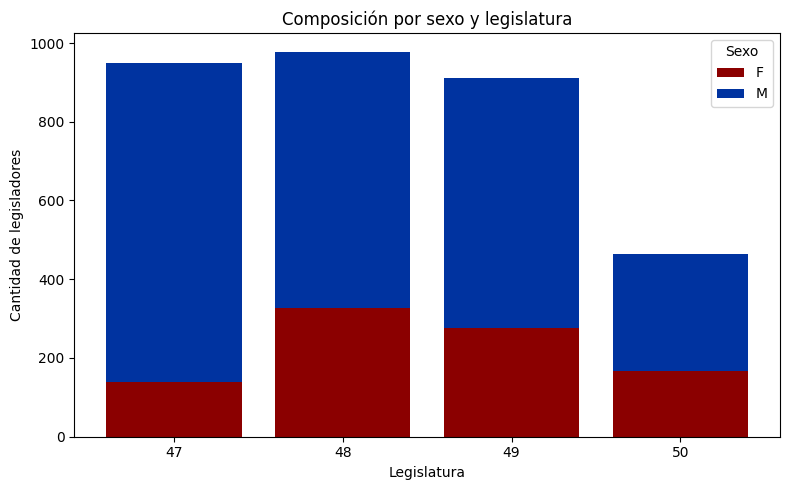

In [28]:
import matplotlib.pyplot as plt 

# Agrupación
df_agg = df_legis_final.groupby(["n_legislatura", "sexo"]).size().reset_index(name="cantidad")

# Pivot para stacked bar
pivot = df_agg.pivot(index="n_legislatura", columns="sexo", values="cantidad").fillna(0)

# Colores asignados manualmente
color_map = {
    "M": "#0033A0",   # azul francés
    "F": "#8B0000",    # rojo oscuro
}

# Crear gráfico
fig, ax = plt.subplots(figsize=(8, 5))

bottom = None
for sexo in pivot.columns:
    ax.bar(
        pivot.index,
        pivot[sexo],
        bottom=bottom,
        label=sexo,
        color=color_map.get(sexo, "#555")  # fallback por si aparece una categoría extra
    )
    if bottom is None:
        bottom = pivot[sexo]
    else:
        bottom += pivot[sexo]

# Forzar eje X discreto
ax.set_xticks([47, 48, 49, 50])

# Etiquetas
ax.set_title("Composición por sexo y legislatura")
ax.set_xlabel("Legislatura")
ax.set_ylabel("Cantidad de legisladores")
ax.legend(title="Sexo")

plt.tight_layout()
plt.show()


In [27]:
df_agg = df_legis.groupby(["camara","sexo"]).size().reset_index(name="cantidad")

px.bar(
    df_agg,
    x="camara",
    y="cantidad",
    color="sexo",
    barmode="stack",
    title="Composición por sexo por Cámara"
)


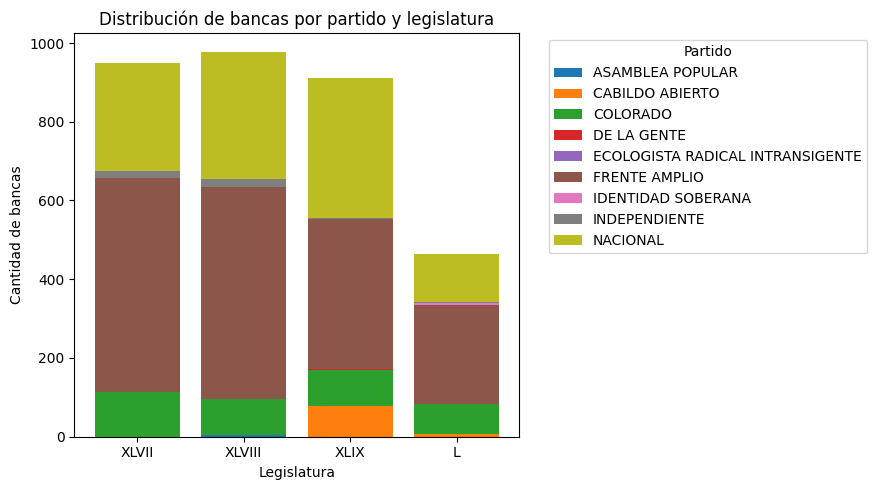

In [ ]:
import matplotlib.pyplot as plt

# Agrupación equivalente
df_agg = df_legis_final.groupby(["n_legislatura", "partido"]).size().reset_index(name="bancas")

# Pivot para stacked bars
pivot = df_agg.pivot(index="n_legislatura", columns="partido", values="bancas").fillna(0)

# Crear gráfico
fig, ax = plt.subplots(figsize=(9, 5))

bottom = None
for partido in pivot.columns:
    ax.bar(
        pivot.index,
        pivot[partido],
        bottom=bottom,
        label=partido
    )
    if bottom is None:
        bottom = pivot[partido]
    else:
        bottom += pivot[partido]

# Eje X discreto con etiquetas romanas
ax.set_xticks([47, 48, 49, 50])
ax.set_xticklabels(["XLVII", "XLVIII", "XLIX", "L"])

# Estética
ax.set_title("Distribución de bancas por partido y legislatura")
ax.set_xlabel("Legislatura")
ax.set_ylabel("Cantidad de bancas")
ax.legend(title="Partido", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()


In [ ]:
df_f = (
    df_legis[df_legis["sexo_asignado"]=="F"]
    .groupby("partido")
    .size()
    .rename("mujeres")
)

df_total = df_legis.groupby("partido").size().rename("total")

pd.concat([df_f, df_total], axis=1).assign(
    porcentaje=lambda d: d["mujeres"]/d["total"]
)


,mujeres,total,porcentaje
partido,,,
ASAMBLEA POPULAR,1.0,5,0.200000
CABILDO ABIERTO,22.0,85,0.258824
COLORADO,89.0,373,0.238606
FRENTE AMPLIO,452.0,1712,0.264019
IDENTIDAD SOBERANA,3.0,4,0.750000
INDEPENDIENTE,11.0,44,0.250000
NACIONAL,330.0,1075,0.306977
DE LA GENTE,NaN,2,NaN
ECOLOGISTA RADICAL INTRANSIGENTE,NaN,1,NaN


In [ ]:
df_comp = (
    df_legis.groupby(["legislatura", "camara", "sexo_asignado"])
      .size()
      .reset_index(name="cantidad")
)

df_comp


px.bar(
    df_comp,
    x="legislatura",
    y="cantidad",
    color="sexo_asignado",
    facet_row="camara",
    barmode="stack",
    title="Composición por sexo en cada Cámara por legislatura",
    height=700
)



In [ ]:
df_part = (
    df_legis.groupby(["legislatura", "camara", "partido", "sexo_asignado"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
      .rename(columns={"F": "cantidad_F", "M": "cantidad_M"})
)

df_part["total"] = df_part["cantidad_F"] + df_part["cantidad_M"]
df_part["pct_F"] = df_part["cantidad_F"] / df_part["total"]

df_part


sexo_asignado,legislatura,camara,partido,cantidad_F,cantidad_M,total,pct_F
0,L,CRR,CABILDO ABIERTO,4,4,8,0.500000
1,L,CRR,COLORADO,10,44,54,0.185185
2,L,CRR,FRENTE AMPLIO,61,73,134,0.455224
3,L,CRR,IDENTIDAD SOBERANA,3,1,4,0.750000
4,L,CRR,INDEPENDIENTE,1,1,2,0.500000
5,L,CRR,NACIONAL,26,61,87,0.298851
6,L,CSS,COLORADO,4,17,21,0.190476
7,L,CSS,FRENTE AMPLIO,47,71,118,0.398305
8,L,CSS,NACIONAL,12,23,35,0.342857
9,XLIX,CRR,CABILDO ABIERTO,15,25,40,0.375000


In [ ]:
df_legis_final

,n_legislatura,camara,partido,apellido_norm,nombre_norm,sexo,condicion,sustituye_a,detalles_texto
0,47,CSS,FRENTE AMPLIO,topolansky,lucia,F,Actuante,NaN,NaN
1,47,CSS,NACIONAL,abreu,sergio,M,Actuante,NaN,NaN
2,47,CSS,FRENTE AMPLIO,agazzi,ernesto,M,Actuante,NaN,NaN
3,47,CSS,COLORADO,amorin,jose,M,Actuante,NaN,NaN
4,47,CSS,FRENTE AMPLIO,baraibar,carlos,M,Actuante,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3556,50,CSS,FRENTE AMPLIO,gandolfo,javier,M,Actuante,"la Senadora Díaz, Bettiana durante la licencia...",NaN
3557,50,CSS,FRENTE AMPLIO,gandolfo,javier,M,Actuante,"la Senadora Díaz, Bettiana durante la licencia...",NaN
3558,50,CRR,FRENTE AMPLIO,brunel sosa,julio,M,Actuante,NaN,NaN
3559,50,CRR,COLORADO,barros pereira,eduardo,M,Actuante,NaN,NaN
